In [17]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv("datasets/car_prices_clean.csv")

print("Tamaño original:", df.shape)
df.head()

Tamaño original: (472325, 16)


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,California,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,California,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,California,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,California,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,California,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [19]:
sample_frac = 0.6

df_sample = (
    df
    .groupby("make", group_keys=False)
    .apply(lambda x: x.sample(frac=sample_frac, random_state=42))
)

print("Tamaño muestra:", df_sample.shape)

Tamaño muestra: (283397, 16)


C:\Users\packo\AppData\Local\Temp\ipykernel_18824\2645030897.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=sample_frac, random_state=42))


In [20]:
orig_prices = df["sellingprice"]
sample_prices = df_sample["sellingprice"]

ks_stat, ks_p = stats.ks_2samp(orig_prices, sample_prices)

print("KS statistic:", ks_stat)
print("p-value:", ks_p)

if ks_p > 0.05:
    print("No se rechaza H0: la distribución de precios es similar.")
else:
    print("Se rechaza H0: la muestra no refleja bien los precios.")

KS statistic: 0.0008640091168947706
p-value: 0.9993767971012758
No se rechaza H0: la distribución de precios es similar.


In [21]:
orig_dist = df["make"].value_counts(normalize=True)
sample_dist = df_sample["make"].value_counts(normalize=True)

comparison = pd.concat([orig_dist, sample_dist], axis=1).fillna(0)
comparison.columns = ["original", "sample"]

chi_stat, chi_p = stats.chisquare(
    f_obs=comparison["sample"],
    f_exp=comparison["original"]
)

print("Chi-square:", chi_stat)
print("p-value:", chi_p)

if chi_p > 0.05:
    print("No se rechaza H0: la distribución por marca es similar.")
else:
    print("Se rechaza H0: la muestra no respeta bien las marcas.")


Chi-square: 1.5023591182983686e-06
p-value: 1.0
No se rechaza H0: la distribución por marca es similar.


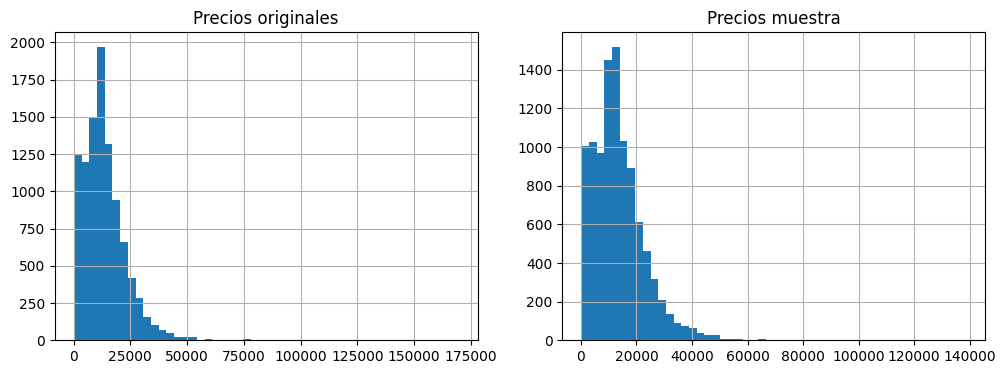

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

orig_prices.sample(10000).hist(ax=ax[0], bins=50)
ax[0].set_title("Precios originales")

sample_prices.sample(10000).hist(ax=ax[1], bins=50)
ax[1].set_title("Precios muestra")

plt.show()


In [23]:
print("Resumen:")
print("Filas originales:", len(df))
print("Filas muestra:", len(df_sample))
print("Proporción:", len(df_sample)/len(df))
print("KS p-value:", ks_p)
print("Chi-square p-value:", chi_p)


Resumen:
Filas originales: 472325
Filas muestra: 283397
Proporción: 0.6000042343725189
KS p-value: 0.9993767971012758
Chi-square p-value: 1.0


In [24]:
df_sample.to_csv("vehicle_sales_sample.csv", index=False)
